In [1]:
import warnings
import pyfolio as pf
from openbb import obb
import pandas as pd
obb.user.preferences.output_type="dataframe"
warnings.filterwarnings("ignore")


/Users/vaibhav/anaconda3/envs/my_quant_lab/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# close=obb.equity.price.historical(
#     "AAPL",
#     start_date="2010-01-01",
#     end_date="2024-07-31",
#     provider="yfinance"
    
# ).close

close=obb.equity.price.historical(
    "AAPL",
    start_date="2010-01-01",
    end_date="2025-07-31",
    provider="yfinance"
).close


<Axes: xlabel='date'>

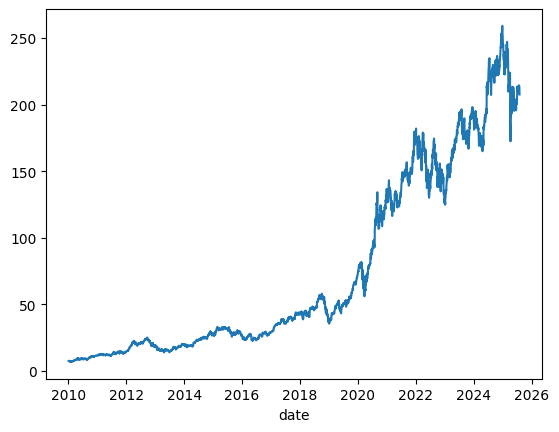

In [3]:
close.plot()

<Axes: xlabel='date'>

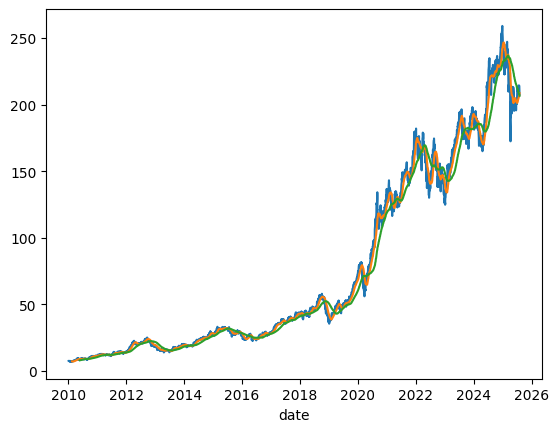

In [4]:
close.plot()
close.rolling(30).mean().plot()
close.rolling(100).mean().plot()
# close.rolling(300).mean().plot()

Start date,2010-01-04
End date,2025-07-31
Total months,186
,Backtest
Annual return,23.659%
Cumulative returns,2615.742%
Annual volatility,28.317%
Sharpe ratio,0.89
Calmar ratio,0.53
Stability,0.96
Max drawdown,-44.377%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,44.38,2012-09-19,2013-04-19,2014-08-19,500
1,38.73,2018-10-03,2019-01-03,2019-10-11,268
2,33.43,2024-12-26,2025-04-08,NaT,NaN
3,32.08,2015-02-23,2016-05-12,2017-02-13,516
4,31.43,2020-02-12,2020-03-23,2020-06-05,83


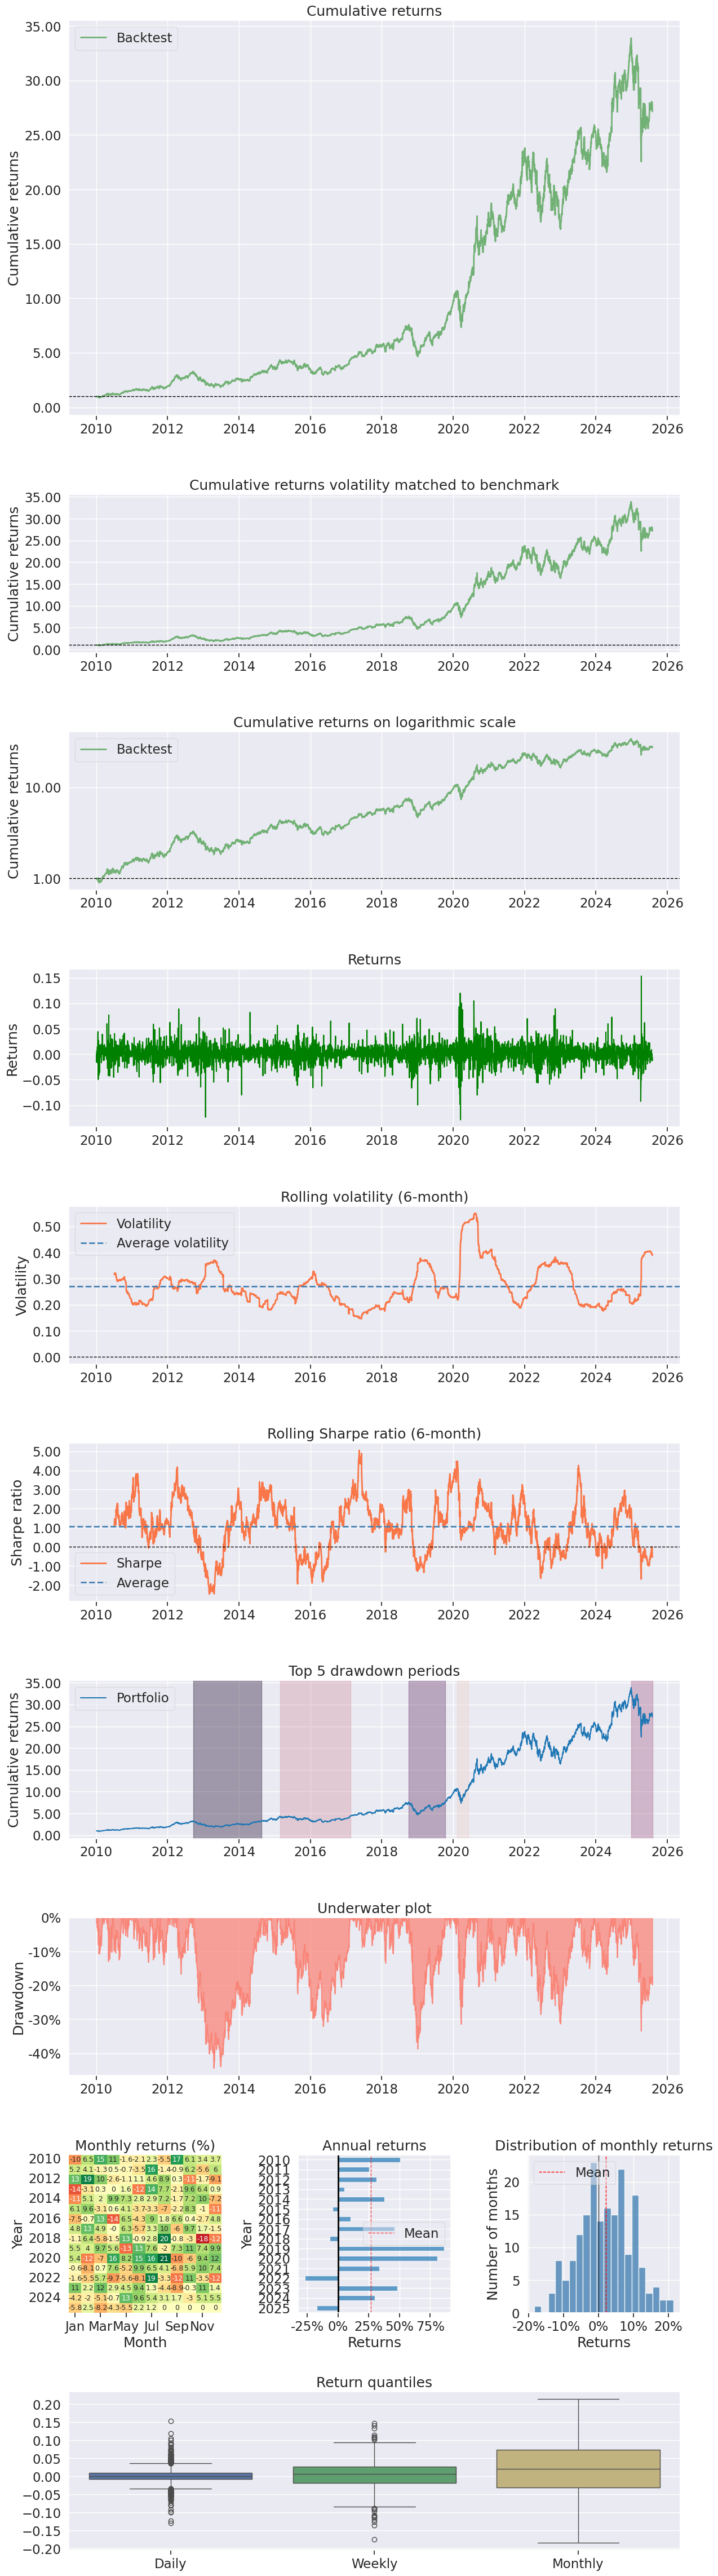

In [5]:
returns=close.pct_change()
returns.index=pd.to_datetime(returns.index)
pf.create_full_tear_sheet(returns)


In [6]:
from threading import Thread
from ibapi.client import EClient
from ibapi.wrapper import EWrapper

class IBapi(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)

app = IBapi()
app.connect("127.0.0.1", 7497, clientId=1)
Thread(target=app.run, daemon=True).start()

ERROR -1 502 Couldn't connect to TWS. Confirm that "Enable ActiveX and Socket EClients" 
is enabled and connection port is the same as "Socket Port" on the 
TWS "Edit->Global Configuration...->API->Settings" menu. Live Trading ports: 
TWS: 7496; IB Gateway: 4001. Simulated Trading ports for new installations 
of version 954.1 or newer:  TWS: 7497; IB Gateway: 4002


In [7]:
# from threading import Thread
# from ibapi.client import EClient
# from ibapi.wrapper import EWrapper

# class IBapi(EWrapper, EClient):
#     def __init__(self):
#         EClient.__init__(self, self)

# app = IBapi()
# app.connect("127.0.0.1", 7497, clientId=1)
# Thread(target=app.run, daemon=True).start()

In [8]:
app.disconnect()

Step 2: Write the Minimum Viable Python with pandas


In [9]:
import warnings
import pandas as pd
import numpy as np
import pyfolio as pf
from openbb import obb
obb.user.preferences.output_type="dataframe"
warnings.filterwarnings("ignore")


In [10]:
#This is the number of days we will look back to
# calculate the rolling z-score

window = 22
#This is the number of standard deviatio the 
#z-score need to be above or below to trigger
# a trading signal

thresh = 2

#set the start date to today and end day to 
#two calendar years ago

today = pd.Timestamp.today().strftime("%Y-%m-%d")
start_date=(pd.Timestamp.today()-pd.Timedelta(days=365*2)).strftime("%Y-%m-%d")

In [11]:
today
start_date

'2023-08-26'

Data Fetching

In [12]:
#Create a simple helper function to grab futures data.
def fetch_futures_from_openbb(ticker, start_date, end_date, expiry=None):
    data = obb.derivatives.futures.historical(ticker,start_date,end_date,provider="yfinance")
    data.rename(columns={"close":ticker},inplace=True)
    data.index = pd.to_datetime(data.index)
    data.index = data.index.normalize()
    return data[ticker]
    

In [13]:
#openBB provides access to individial futures data which is fine
# for our strategy, This is heating oil,gasoline, and crude oil
#futures data.

ho =  fetch_futures_from_openbb("HO=F", start_date,today)
rb =  fetch_futures_from_openbb("RB=F", start_date,today)
cl =  fetch_futures_from_openbb("CL=F", start_date,today)

# Get the refiener stock data for the same time range

psx= obb.equity.price.historical(
    "PSX",
    start_date=start_date,
    end_date=today,
    provider="yfinance"   
).close

psx.name="PSX"
#now put all the series together
data=pd.concat([ho,rb,cl,psx],axis=1).dropna()


In [14]:
data

,HO=F,RB=F,CL=F,PSX
date,,,,
2023-08-28,3.2037,2.7957,80.099998,113.129997
2023-08-29,3.2095,2.7905,81.160004,112.690002
2023-08-30,3.0962,2.8092,81.629997,113.650002
2023-08-31,3.1426,2.7664,83.629997,114.160004
2023-09-01,3.1050,2.5912,85.550003,117.169998
...,...,...,...,...
2025-08-19,2.2511,2.0890,62.349998,122.169998
2025-08-20,2.2796,2.1283,63.209999,123.570000
2025-08-21,2.3251,2.1597,63.520000,124.449997


In [15]:
# Create a simple helper function to grab futures data.
def fetch_futures_from_openbb(ticker, start_date, end_date, expiry=None):
    data = obb.derivatives.futures.historical(ticker, start_date, end_date, provider="yfinance")
    data.rename(columns={"close": ticker}, inplace=True)
    data.index = pd.to_datetime(data.index)
    data.index = data.index.normalize()
    return data[ticker]

# OpenBB provides access to individual futures data which is fine
# for our strategy. This is heating oil, gasoline, and crude oil
# futures data.
ho = fetch_futures_from_openbb("HO=F", start_date, today)
rb = fetch_futures_from_openbb("RB=F", start_date, today)
cl = fetch_futures_from_openbb("CL=F", start_date, today)

# Get the refiner stock data for the same time range.
psx = obb.equity.price.historical(
    "PSX", 
    start_date=start_date, 
    end_date=today,
    provider="yfinance"
).close
psx.name = "PSX"

# Now put all the prices together.
data = pd.concat([ho, rb, cl, psx], axis=1).dropna()

In [16]:
#compute the price per barrel
rb *= 42
ho *=42

#construct the crack spread
data["crack_spread"] =2 * rb + ho- 3 * cl
data["crack_spread"] /=3

# Gasoline (rb) and Heating Oil (ho) futures are quoted in $/gallon.
# Crude Oil (cl) futures are quoted in $/barrel.
# gallon * 42 = barrel

In [17]:
data

,HO=F,RB=F,CL=F,PSX,crack_spread
date,,,,,
2023-08-28,3.2037,2.7957,80.099998,113.129997,43.031404
2023-08-29,3.2095,2.7905,81.160004,112.690002,41.906995
2023-08-30,3.0962,2.8092,81.629997,113.650002,40.374404
2023-08-31,3.1426,2.7664,83.629997,114.160004,37.825606
2023-09-01,3.1050,2.5912,85.550003,117.169998,30.473600
...,...,...,...,...,...
2025-08-19,2.2511,2.0890,62.349998,122.169998,27.657402
2025-08-20,2.2796,2.1283,63.209999,123.570000,28.296798
2025-08-21,2.3251,2.1597,63.520000,124.449997,29.502996


<Axes: xlabel='date'>

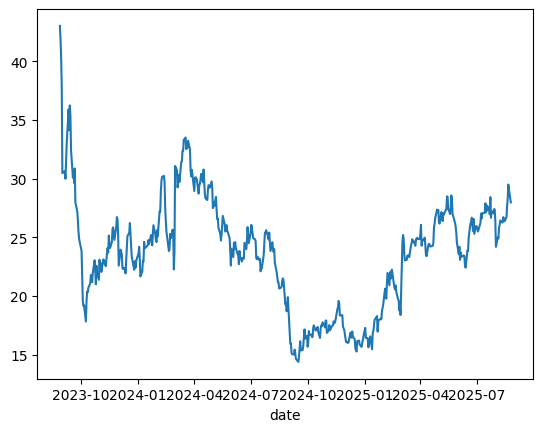

In [18]:
data.crack_spread.plot()

In [19]:
data['spread']=data.crack_spread-data.PSX

In [20]:
data

,HO=F,RB=F,CL=F,PSX,crack_spread,spread
date,,,,,,
2023-08-28,3.2037,2.7957,80.099998,113.129997,43.031404,-70.098593
2023-08-29,3.2095,2.7905,81.160004,112.690002,41.906995,-70.783007
2023-08-30,3.0962,2.8092,81.629997,113.650002,40.374404,-73.275598
2023-08-31,3.1426,2.7664,83.629997,114.160004,37.825606,-76.334397
2023-09-01,3.1050,2.5912,85.550003,117.169998,30.473600,-86.696398
...,...,...,...,...,...,...
2025-08-19,2.2511,2.0890,62.349998,122.169998,27.657402,-94.512596
2025-08-20,2.2796,2.1283,63.209999,123.570000,28.296798,-95.273201
2025-08-21,2.3251,2.1597,63.520000,124.449997,29.502996,-94.947001


In [21]:
data['return']=np.log(data.spread/data.spread.shift(1))
data.head(5)

,HO=F,RB=F,CL=F,PSX,crack_spread,spread,return
date,,,,,,,
2023-08-28,3.2037,2.7957,80.099998,113.129997,43.031404,-70.098593,NaN
2023-08-29,3.2095,2.7905,81.160004,112.690002,41.906995,-70.783007,0.009716
2023-08-30,3.0962,2.8092,81.629997,113.650002,40.374404,-73.275598,0.034609
2023-08-31,3.1426,2.7664,83.629997,114.160004,37.825606,-76.334397,0.040896
2023-09-01,3.1050,2.5912,85.550003,117.169998,30.473600,-86.696398,0.127289


In [22]:
data['z']=(data.spread-data.spread.rolling(window=window).mean())/data.spread.rolling(window=window).std()

In [23]:
data.tail()

,HO=F,RB=F,CL=F,PSX,crack_spread,spread,return,z
date,,,,,,,,
2025-08-19,2.2511,2.0890,62.349998,122.169998,27.657402,-94.512596,-0.016991,0.815507
2025-08-20,2.2796,2.1283,63.209999,123.570000,28.296798,-95.273201,0.008015,0.450569
2025-08-21,2.3251,2.1597,63.520000,124.449997,29.502996,-94.947001,-0.003430,0.520254
2025-08-22,2.3081,2.1585,63.660000,129.940002,29.091399,-100.848604,0.060302,-1.872842
2025-08-25,2.3316,2.1378,64.519997,129.520004,27.980802,-101.539202,0.006825,-1.900404


In [24]:
thresh
data["position"] = np.select(
    [data.z < - thresh,data.z > thresh],
    [1,-1],
    default=0    
)


In [25]:
data[data.position >0]

,HO=F,RB=F,CL=F,PSX,crack_spread,spread,return,z,position
date,,,,,,,,,
2023-11-02,3.0255,2.2460,82.459999,118.120003,22.785003,-95.335000,0.015433,-2.008251,1
2023-11-30,2.8305,2.1998,75.959999,128.889999,25.261400,-103.628600,0.079593,-3.437196,1
2023-12-01,2.6615,2.1211,74.070000,129.699997,22.581799,-107.118198,0.033120,-3.104932,1
2023-12-04,2.6597,2.1342,73.040001,128.440002,23.953401,-104.486602,-0.024874,-2.122806,1
2024-01-30,2.8068,2.2607,77.820000,142.410004,24.774798,-117.635205,0.033169,-2.086064,1
2024-01-31,2.8082,2.1833,75.849998,144.309998,24.597200,-119.712797,0.017507,-2.188246,1
2024-03-15,2.7270,2.7208,81.040001,159.029999,33.320397,-125.709602,0.029753,-2.261356,1
2024-03-28,2.6156,2.7611,83.169998,163.339996,30.759205,-132.580791,0.029257,-2.162981,1
2024-04-01,2.6271,2.7100,83.709999,163.339996,28.949402,-134.390594,0.013558,-2.120493,1


In [26]:
strategy_returns = data.position.shift(1) * data["return"]

In [27]:
strategy_returns.index=pd.to_datetime(strategy_returns.index)



Start date,2023-08-28
End date,2025-08-25
Total months,23
,Backtest
Annual return,8.775%
Cumulative returns,18.163%
Annual volatility,18.719%
Sharpe ratio,0.54
Calmar ratio,0.59
Stability,0.57
Max drawdown,-14.917%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,14.92,2025-04-08,2025-04-09,NaT,NaN
1,8.18,2025-02-11,2025-03-06,2025-04-04,39
2,7.10,2024-04-03,2024-10-07,2024-12-18,186
3,3.43,2023-12-01,2024-03-18,2024-04-02,88
4,0.63,2023-11-02,2023-11-03,2023-12-01,22


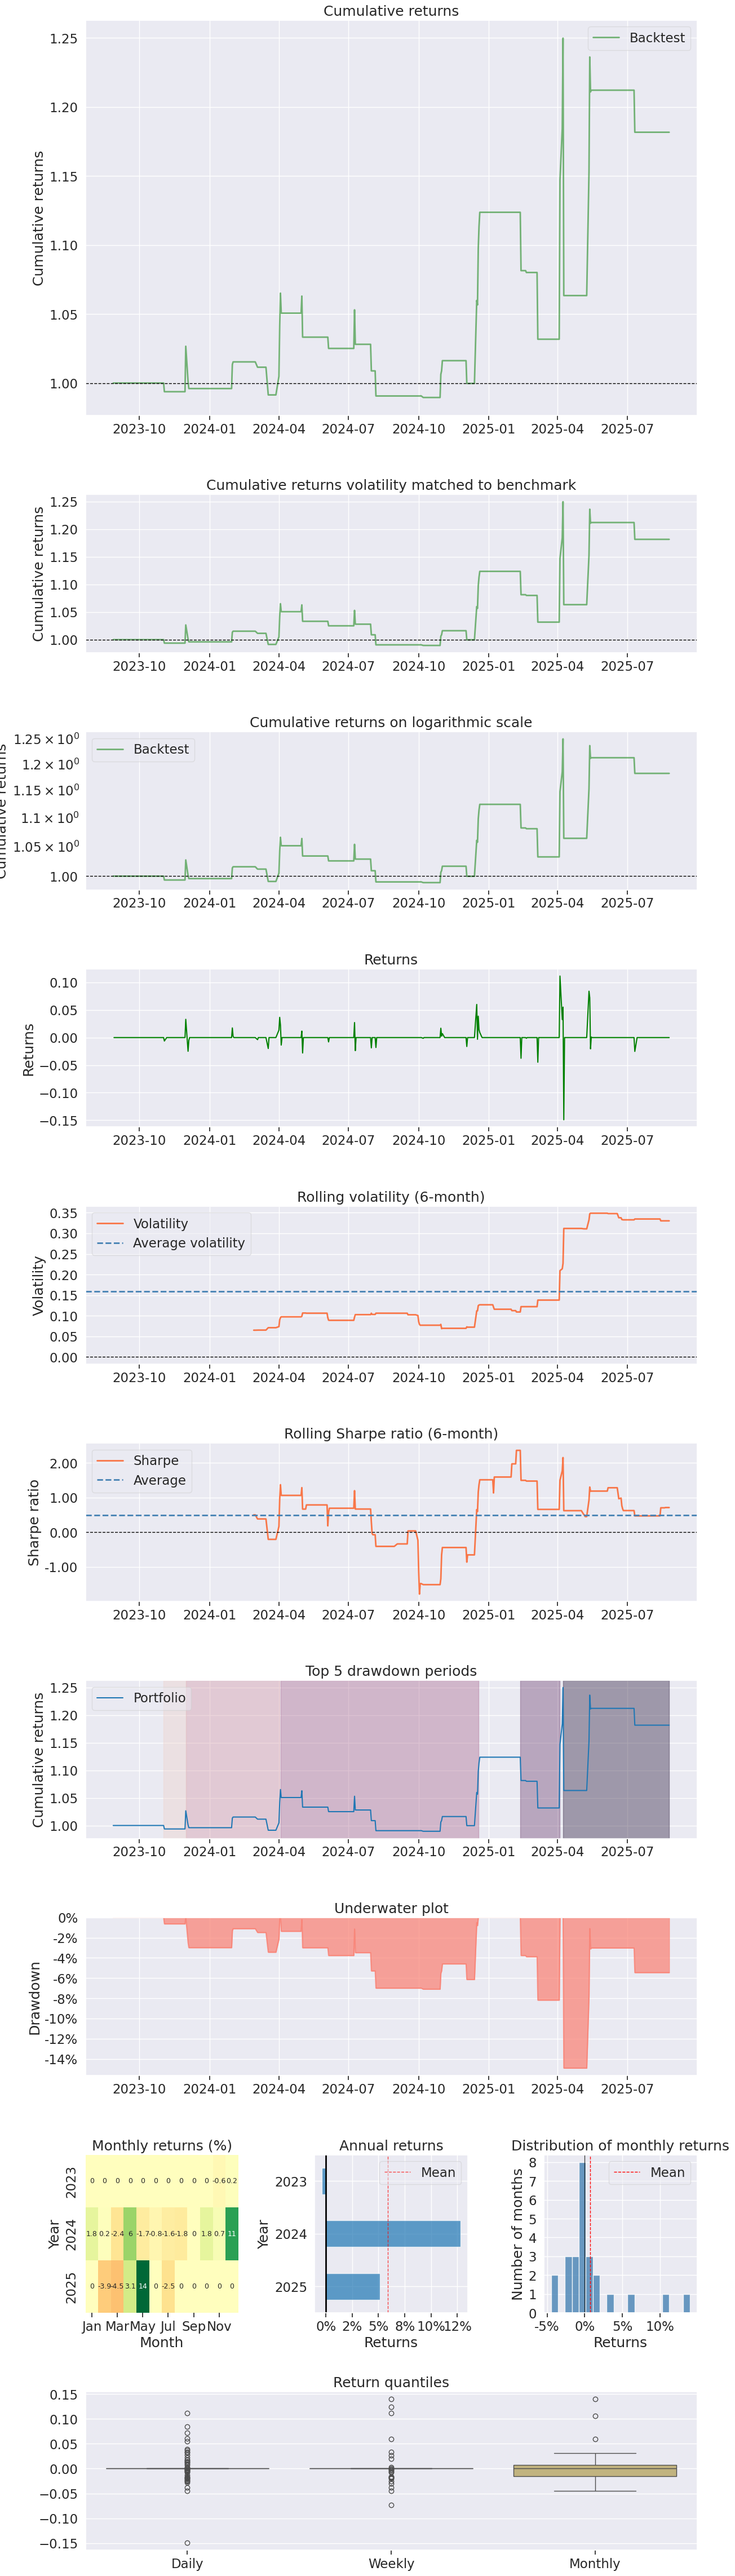

In [28]:
pf.create_full_tear_sheet(strategy_returns)

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

Step 3: Write the Minimum Viable Python with pandas
Backtest your strategy idea using VectorBT

In [29]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import vectorbt as vbt



In [30]:
# This is the number of days we'll look back to 
# calculate the rolling z-score.
window = 22

# This is the number of standard deviations the 
# z-score needs to be above or below to trigger
# a trading signal.`
thresh = 2

In [31]:
# Use the VectorBT data download functionality to
# grab price history data.
data = vbt.YFData.download(
    [
        "CL=F", 
        "RB=F", 
        "HO=F", 
        "PSX"
    ], 
    start="2020-01-01 UTC", 
    end="2023-12-31 UTC",
    missing_index="drop"
)

crack_spread=0

In [32]:
# The data object requires us to extract the data.
cl = data.get("Close")["CL=F"]
rb = data.get("Close")["RB=F"]
ho = data.get("Close")["HO=F"]
psx = data.get("Close")["PSX"]

In [33]:
rb

Date
2020-01-02 05:00:00+00:00    1.7042
2020-01-03 05:00:00+00:00    1.7488
2020-01-06 05:00:00+00:00    1.7544
2020-01-07 05:00:00+00:00    1.7222
2020-01-08 05:00:00+00:00    1.6488
                              ...  
2023-12-22 05:00:00+00:00    2.1301
2023-12-26 05:00:00+00:00    2.1583
2023-12-27 05:00:00+00:00    2.1550
2023-12-28 05:00:00+00:00    2.0852
2023-12-29 05:00:00+00:00    2.1026
Name: RB=F, Length: 1006, dtype: float64

In [34]:
#compute price per barrel for RBOB gasoline(rb) from per Gallon by Multiplying by 42
#compute price per barrel for heating oil (ho) from per Gallon by Multiplying by 42
#price of WTI crude is already quoted in dollars per barrel
# lastly at the end we need to divide by 3 to get price per barrel insread of 3 barrels

#compute price per barrel
rb *=42
ho *=42

# construct the crack spread
crack_spread =  2 * rb + ho - 3 * cl
crack_spread /= 3 

In [35]:
spread = crack_spread - psx

In [36]:
zscore= (
spread- spread.rolling(window=window).mean())/spread.rolling(window=window).std()
    


In [37]:
zscore

Date
2020-01-02 05:00:00+00:00         NaN
2020-01-03 05:00:00+00:00         NaN
2020-01-06 05:00:00+00:00         NaN
2020-01-07 05:00:00+00:00         NaN
2020-01-08 05:00:00+00:00         NaN
                               ...   
2023-12-22 05:00:00+00:00   -1.401022
2023-12-26 05:00:00+00:00   -1.730930
2023-12-27 05:00:00+00:00   -1.318808
2023-12-28 05:00:00+00:00   -1.048589
2023-12-29 05:00:00+00:00   -1.014067
Length: 1006, dtype: float64

In [38]:
long_entries =  zscore.vbt.crossed_below(-thresh)
long_exits = zscore.vbt.crossed_above(thresh)

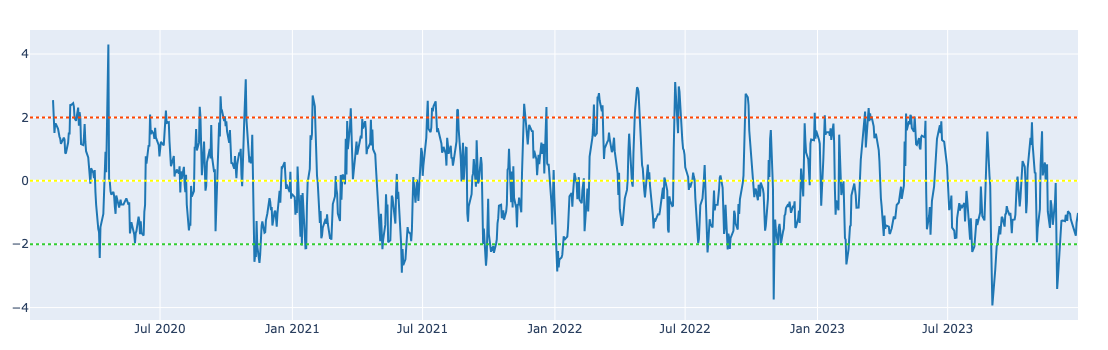

In [39]:
fig = zscore.vbt.plot()
fig.add_hline(y=thresh, line_color="orangered",line_dash="dot")
fig.add_hline(y=0, line_color="yellow",line_dash="dot")
fig.add_hline(y=-thresh, line_color="limegreen",line_dash="dot")
fig.show()              




In [40]:
#Run a backtest based on the prices, long, and short entries and exists
perf =  vbt.Portfolio.from_signals(
    psx,
    entries=long_entries,
    exits=long_exits,
    freq="1D"

)
    


<Axes: xlabel='Date'>

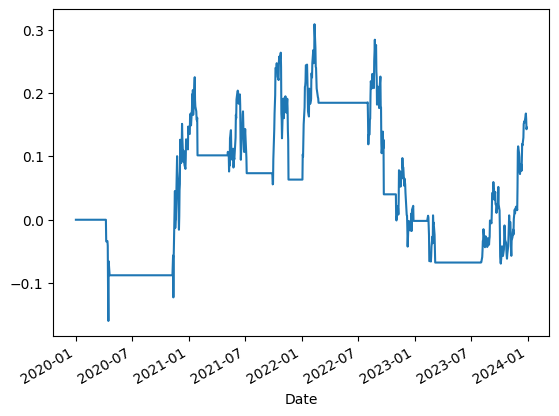

In [41]:
perf.cumulative_returns().plot()

In [42]:
perf.stats()

Start                         2020-01-02 05:00:00+00:00
End                           2023-12-29 05:00:00+00:00
Period                               1006 days 00:00:00
Start Value                                       100.0
End Value                                    114.539292
Total Return [%]                              14.539292
Benchmark Return [%]                           41.86485
Max Gross Exposure [%]                            100.0
Total Fees Paid                                     0.0
Max Drawdown [%]                               28.86236
Max Drawdown Duration                 472 days 00:00:00
Total Trades                                          9
Total Closed Trades                                   8
Total Open Trades                                     1
Open Trade PnL                                21.290516
Win Rate [%]                                       25.0
Best Trade [%]                                20.734023
Worst Trade [%]                              -12

Step 4: Assess the risk and performance metrics 

Step 4: Assess the risk and performance metrics 

Step 4: Assess the risk and performance metrics 

Step 4: Assess the risk and performance metrics 

Step 4: Assess the risk and performance metrics 

Step 4: Assess the risk and performance metrics 

Step 4: Assess the risk and performance metrics 

In [43]:
print(f"The Sharpe Ratio of the backtest is :{perf.sharpe_ratio()}")

The Sharpe Ratio of the backtest is :0.31778631889816833


In [44]:
print(f"The maximum drawdown of the backtest is : {perf.max_drawdown()}")

The maximum drawdown of the backtest is : -0.28862360225280526


In [45]:
perf.plot_cum_returns()

FigureWidget({
    'data': [{'line': {'color': '#7f7f7f'},
              'name': 'Benchmark',
              'showlegend': True,
              'type': 'scatter',
              'uid': '5921e773-7435-4b56-86b1-3674664c41e9',
              'x': array([datetime.datetime(2020, 1, 2, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 6, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([1.        , 0.96693398, 0.96087347, ..., 1.43527073, 1.41545159,
                          1.4186485 ])},
             {'hoverinfo': 'skip',
 

In [46]:
#Drawdown Plots
perf.plot_drawdowns()


FigureWidget({
    'data': [{'line': {'color': '#9467bd'},
              'name': 'Value',
              'showlegend': True,
              'type': 'scatter',
              'uid': '6f87c701-ee09-4270-a38e-8ca93fe57a84',
              'x': array([datetime.datetime(2020, 1, 2, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 6, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([100.        , 100.        , 100.        , ..., 115.88134363,
                          114.2811794 , 114.53929245])},
             {'customdata': 

In [47]:
perf.plot_underwater()

FigureWidget({
    'data': [{'fill': 'tozeroy',
              'fillcolor': 'rgba(220,57,18,0.3000)',
              'line': {'color': '#dc3912'},
              'name': 'Drawdown',
              'showlegend': True,
              'type': 'scatter',
              'uid': '06806804-f143-49af-bed5-bc66b4f84869',
              'x': array([datetime.datetime(2020, 1, 2, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 6, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([ 0.        ,  0.        ,  0.        , ..., -0.11437324, 

In [48]:
perf.plot_trades()

FigureWidget({
    'data': [{'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'ee55e3a5-3990-46b7-98d2-c8ca06375391',
              'x': array([datetime.datetime(2020, 1, 2, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 6, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([ 88.33119202,  85.41043091,  84.87509918, ..., 126.7791748 ,
                          125.02852631, 125.31091309])},
             {'customdata': 

In [49]:
# Drawdown Plots
perf.plot_trades()

FigureWidget({
    'data': [{'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'b857d0c0-d169-4975-9bba-4085155017fa',
              'x': array([datetime.datetime(2020, 1, 2, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2020, 1, 6, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([ 88.33119202,  85.41043091,  84.87509918, ..., 126.7791748 ,
                          125.02852631, 125.31091309])},
             {'customdata': 

In [59]:
class Option:
    def __init__(self,right,strike,expiration):
        self.right =  right
        self.strike =  strike
        self.expiration = expiration

    def payoff(self, underlying_price):
            if self.right.lower()=="call":
                 return max(underlying_price - self.strike, 0)
            elif self.right.lower()=="put":
                 return max(self.strike - underlying_price, 0)
            else:
                print(f"error, need the right to be call or put")

    def __str__(self):
        return f"Option(right = {self.right}, strike= {self.strike}, expiration = {self.expiration})"

put = Option("put", 50.0, "2024-12-31")
print(put.payoff(5))

45.0


In [57]:
print(put)

Option(right = put, strike= 50.0, expiration = 2024-12-31)
